# Chapter 17 - Spin Tracking with Ramping

In a perfectly-flat ring (a ring in which the only magnetic fields encountered on the closed orbit are vertical), the closed-orbit spin tune is $\nu_0 = G\gamma$, where $G = (g - 2)/2$ is the anomalous gyromagnetic $g$-factor and $\gamma$ is the reference gamma. We will ramp our ring through the $\nu_0 = 60 - Q_y \approx 51.81$ resonance.

In [1]:
using SciBmad
using CairoMakie
using LinearAlgebra
using Statistics
using Printf

## Load the Spin Lattice

Start with the AGS-like spin lattice distributed with SciBmad. This file is the Julia version of the tutorial `spin_lat.bmad` lattice, and it defines the proton ring used in this example.

In [2]:
# This file mirrors the bmad's 15_SpinTracking/spin_lat.bmad lattice.
spin_lattice_path = joinpath(pkgdir(SciBmad), "lattices", "ags.jl")
include(spin_lattice_path)

@printf("Loaded lattice: %s\n", spin_lattice_path)
@printf("Ring elements: %d\n", length(ring.line))
@printf("Reference species: %s\n", ring.species_ref.name)
@printf("Initial fixed E_ref from lattice file: %.8e eV\n", ring.E_ref)

Loaded lattice: C:\Users\JoeyN\.julia\packages\SciBmad\Cjbj1\lattices\ags.jl
Ring elements: 543
Reference species: proton
Initial fixed E_ref from lattice file: 2.40490243e+10 eV


## Define the Energy Ramp

Let's ramp $G\gamma$ from 51.71 to 51.91 in 5000 turns. Since $G\gamma = GE/m$ for the reference particle, the corresponding reference energy is

$$
E = \frac{G\gamma}{G} m.
$$

For this ring, the revolution time is 2.67024 microseconds. This fixes the linear ramp rate used below.

In [3]:
const CH15_SPECIES = Species("proton")
const CH15_G = gyromagnetic_anomaly(CH15_SPECIES)
const CH15_MASS = massof(CH15_SPECIES)

const G_GAMMA_START = 51.71
const G_GAMMA_STOP = 51.91
const N_TURNS = 5000
const TURN_TIME = 2.67024e-6

energy_from_Ggamma(Ggamma) = Ggamma / CH15_G * CH15_MASS
Ggamma_from_energy(E) = CH15_G * E / CH15_MASS

E_START = energy_from_Ggamma(G_GAMMA_START)
E_STOP = energy_from_Ggamma(G_GAMMA_STOP)
dE_dt = (E_STOP - E_START) / (N_TURNS * TURN_TIME)

@printf("G = %.12f\n", CH15_G)
@printf("E_start = %.8e eV\n", E_START)
@printf("E_stop  = %.8e eV\n", E_STOP)
@printf("dE/dt   = %.8e eV/s\n", dE_dt)

G = 1.792847344650
E_start = 2.70620083e+10 eV
E_stop  = 2.71666767e+10 eV
dE/dt   = 7.83962302e+09 eV/s


In [4]:
# SciBmad version of the ramper.
# During tracking, BeamTracking evaluates Time() from the bunch reference time.
ring.E_ref = E_START + dE_dt * Time()

# At t = 0, the ring starts at G? = 51.71.
@printf("G?(t=0) = %.5f\n", Ggamma_from_energy(ring.E_ref(0.0)))
@printf("G?(t=end) ? %.5f\n", Ggamma_from_energy(ring.E_ref(N_TURNS * TURN_TIME)))

G?(t=0) = 51.71000
G?(t=end) ? 51.91000


## Long-Term Tracking of One Vertically Polarized Proton

The six orbital coordinates are ordered as

$$
(x, p_x, y, p_y, z, p_z).
$$

Track one proton with initial vertical spin, $(S_x, S_y, S_z) = (0, 1, 0)$. Following the SciBmad [`ags-spin-ramp.ipynb`](https://github.com/bmad-sim/SciBmad.jl/blob/main/examples/julia/ags-spin-ramp.ipynb) example, track one turn at a time with `track!` so that the time-dependent reference energy is updated explicitly.

In [ ]:
v0 = [0.0, 0.0, 1e-5, 0.0, 2.66, 1.15e-5]
s0 = [0.0 1.0 0.0]
q0 = [1.0 0.0 0.0 0.0]

b0 = Bunch(reshape(v0, 1, 6), q0;
    species=ring.species_ref,
    p_over_q_ref=ring.p_over_q_ref(0),
)

turns = collect(0:N_TURNS)
spin_history = zeros(N_TURNS + 1, 3)
Ggamma_turn = zeros(N_TURNS + 1)
spin_history[1, :] .= s0
Ggamma_turn[1] = Ggamma_from_energy(ring.E_ref(0))

for i in 1:N_TURNS
    track!(b0, ring; ramp_particle_energy_without_rf=true)
    spin_history[i + 1, :] .= vec(rotate_spins(b0.coords.q, s0))
    Ggamma_turn[i + 1] = Ggamma_from_energy(ring.E_ref(b0.t_ref))
end

@printf("tracked turns: %d\n", N_TURNS)
@printf("final Ggamma = %.8f\n", last(Ggamma_turn))

In [ ]:
Sx = spin_history[:, 1]
Sy = spin_history[:, 2]
Sz = spin_history[:, 3]

@printf("Initial Sy = %.8f\n", first(Sy))
@printf("Final Sy   = %.8f\n", last(Sy))
@printf("Minimum Sy = %.8f\n", minimum(Sy))

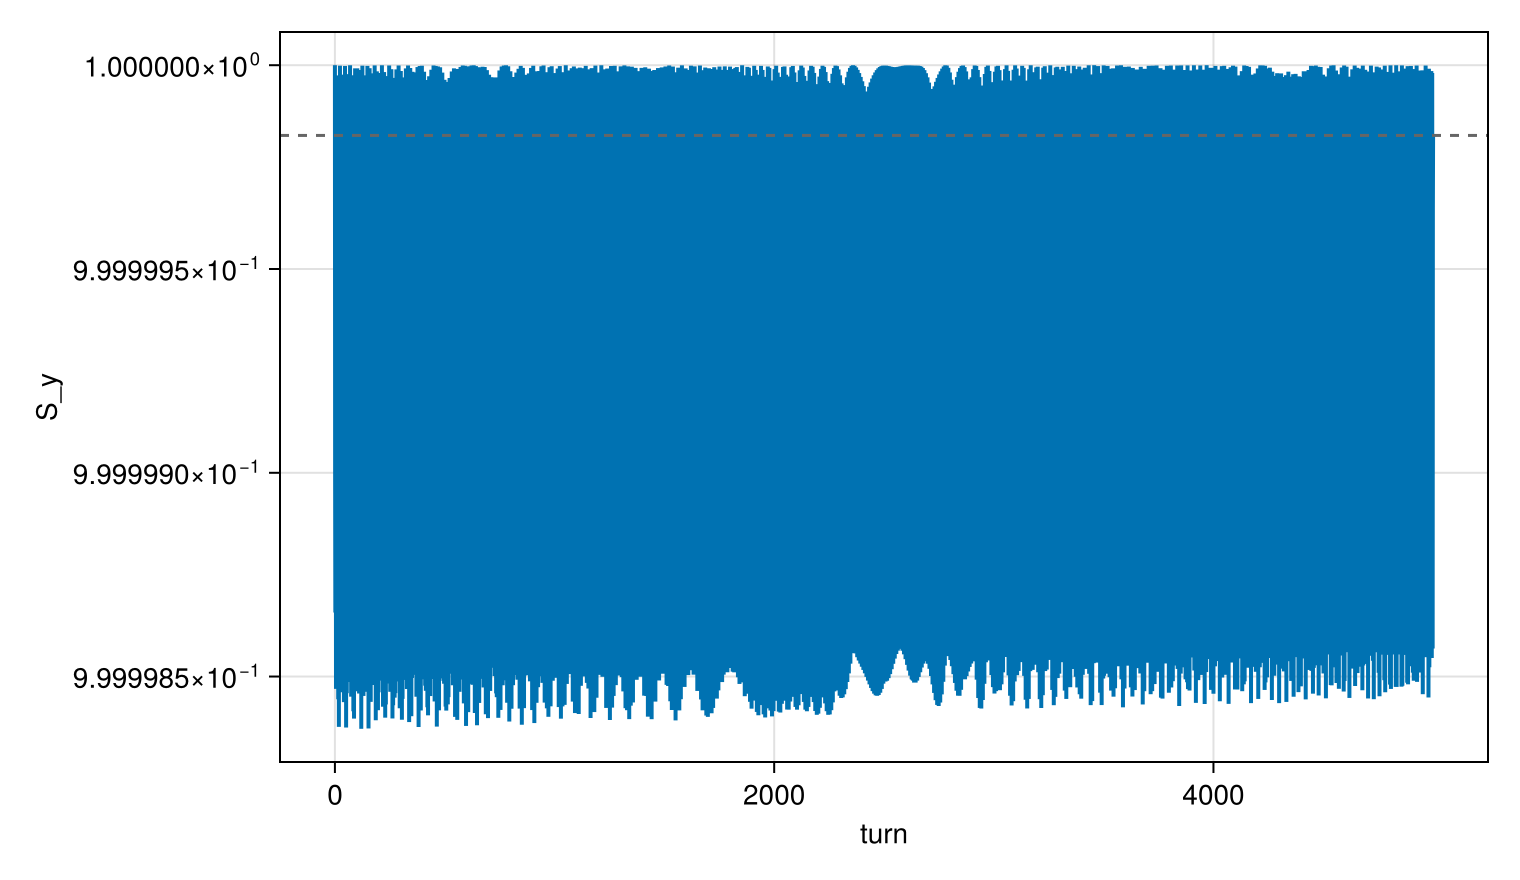

In [7]:
fig = Figure(size=(760, 440))
ax = Axis(fig[1, 1], xlabel="turn", ylabel="S_y")
lines!(ax, turns, Sy, linewidth=2)
hlines!(ax, [last(Sy)], linestyle=:dash, color=:gray40)
fig

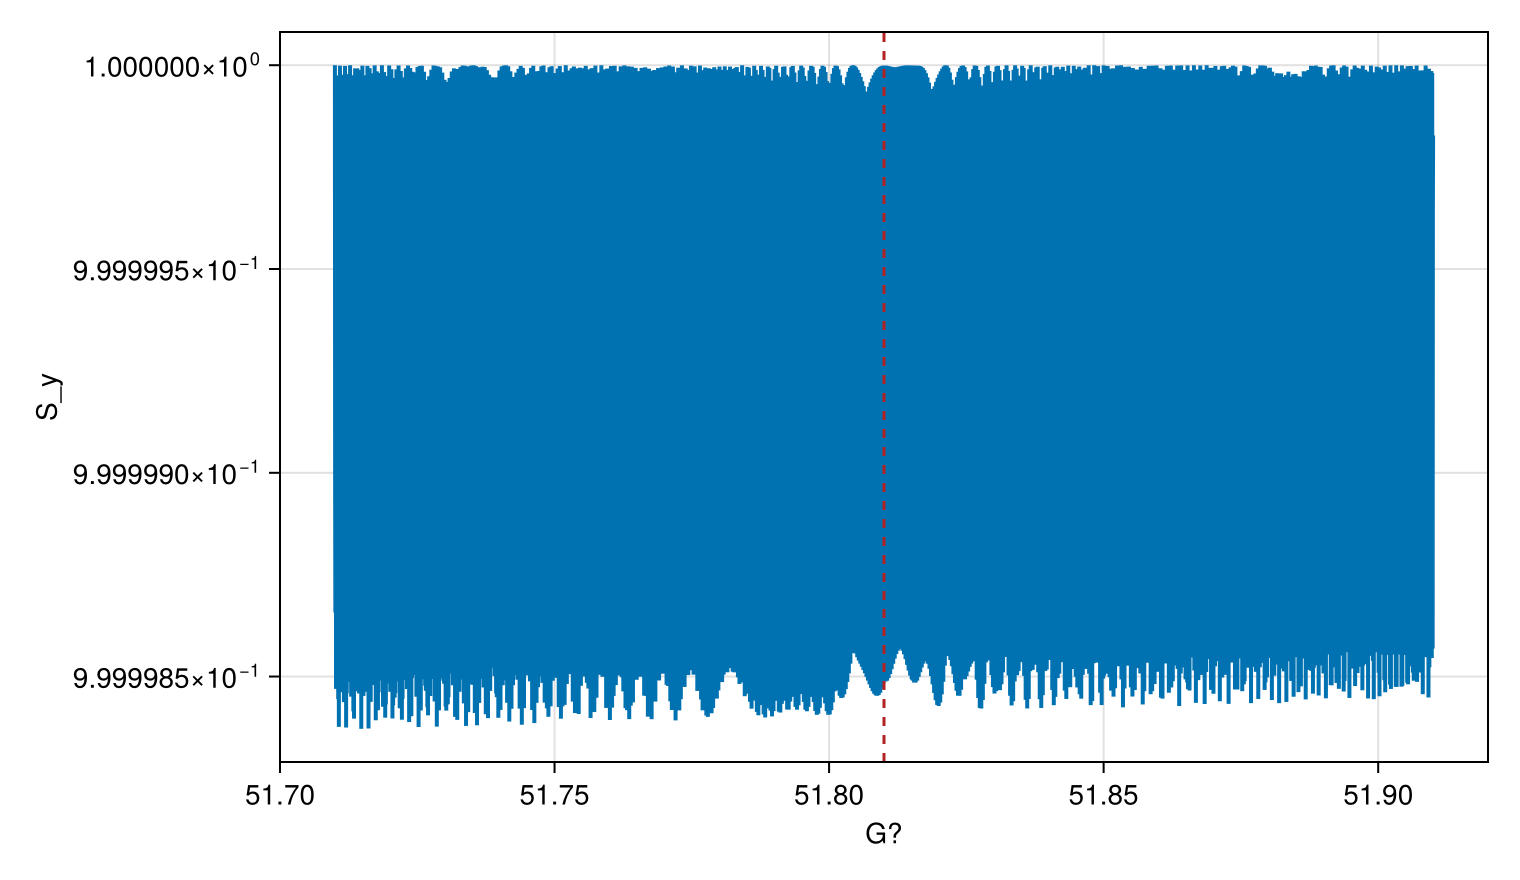

In [8]:
fig = Figure(size=(760, 440))
ax = Axis(fig[1, 1], xlabel="G?", ylabel="S_y")
lines!(ax, Ggamma_turn, Sy, linewidth=2)
vlines!(ax, [51.81], linestyle=:dash, color=:firebrick)
fig

## Froissart-Stora Comparison

We can find what the asymptotic value of $S_y$ should have been using the Froissart-Stora formula:

$$
S_y(\infty) = 2\exp\left(-\frac{\pi \epsilon^2}{2\tilde\alpha}\right) - 1,
$$

where $\epsilon$ is the resonance strength and

$$
\tilde\alpha = \frac{1}{2\pi}\frac{d(G\gamma)}{d\theta}
              = \frac{1}{2\pi}\left[\text{change in }G\gamma\text{ per turn}\right].
$$

Here, $\theta$ is the machine azimuth and $\tilde\alpha$ is the ramp rate. Since this SciBmad calculation gives us the final polarization directly, we first invert this formula to infer the effective resonance strength that would produce the tracked final $S_y$.

In [ ]:
alpha_tilde = (G_GAMMA_STOP - G_GAMMA_START) / N_TURNS / (2pi)

function froissart_stora(epsilon, alpha_tilde)
    return 2exp(-pi * epsilon^2 / (2alpha_tilde)) - 1
end

function epsilon_from_final_polarization(Sy_final, alpha_tilde)
    value = (Sy_final + 1) / 2
    if !(0 < value <= 1)
        return NaN
    end
    return sqrt(-2alpha_tilde / pi * log(value))
end

epsilon_effective = epsilon_from_final_polarization(last(Sy), alpha_tilde)
Sy_reconstructed = froissart_stora(epsilon_effective, alpha_tilde)

@printf("alpha_tilde = %.8e\n", alpha_tilde)
@printf("effective epsilon from tracking = %.8e\n", epsilon_effective)
@printf("Froissart-Stora final Sy = %.8f\n", Sy_reconstructed)
@printf("tracking final Sy = %.8f\n", last(Sy))

## Effective Resonance Strength

In Tao, `show spin -ele 0` prints the normalized resonance strengths `Xi_sum` and `Xi_diff`; for this vertical resonance, the physically relevant one is selected by whichever of the associated fractional tune combinations is closer to zero. SciBmad does not currently have an equivalent command that prints these normalized spin-resonance strengths directly.

So unlike in Tao, we cannot directly read the resonance strength and verify the Froissart-Stora equation. Instead, we infer the true resonance strength $\epsilon_\mathrm{eff}$ from solving the Froissart-Stora formula inversely with the final $S_y$ of our tracking as the asymptotic value. To convert it into an effective normalized strength comparable to Tao's `Xi_sum` or `Xi_diff`, we use

$$
\epsilon = |\mathrm{Xi}|\sqrt{J_y}.
$$

The vertical action $J_y$ is found from the Twiss parameters at the initial point, after setting the reference energy such that the resonance value $G\gamma = 51.81$:

$$
J_y = \frac{1}{2}\left(\gamma_y y^2 + 2\alpha_y y p_y + \beta_y p_y^2\right),
\qquad
\gamma_y = \frac{1 + \alpha_y^2}{\beta_y}.
$$

Thus SciBmad gives us $J_y$ through Twiss, while the resonance strength itself comes from the Froissart-Stora inversion:

$$
\mathrm{Xi}_\mathrm{eff} = \frac{\epsilon_\mathrm{eff}}{\sqrt{J_y}}.
$$


In [ ]:
const G_GAMMA_RESONANCE = 51.81

ring_resonance = deepcopy(ring)
ring_resonance.E_ref = energy_from_Ggamma(G_GAMMA_RESONANCE)
tw_resonance = twiss(ring_resonance)

beta_y0 = tw_resonance.table.beta_2[1]
alpha_y0 = tw_resonance.table.alpha_2[1]
gamma_y0 = (1 + alpha_y0^2) / beta_y0

y0 = v0[3]
py0 = v0[4]
J_y = 0.5 * (gamma_y0 * y0^2 + 2alpha_y0 * y0 * py0 + beta_y0 * py0^2)
xi_effective = epsilon_effective / sqrt(J_y)

@printf("beta_y(0) = %.8e m\n", beta_y0)
@printf("alpha_y(0) = %.8e\n", alpha_y0)
@printf("J_y = %.8e m\n", J_y)
@printf("effective epsilon = %.8e\n", epsilon_effective)
@printf("effective normalized Xi = %.8e\n", xi_effective)

## Check the Spin Norm

As a final check, verify that the spin vector remains normalized during tracking.

In [ ]:
spin_norm = sqrt.(Sx.^2 .+ Sy.^2 .+ Sz.^2)

fig = Figure(size=(760, 360))
ax = Axis(fig[1, 1], xlabel="turn", ylabel="|S| - 1")
lines!(ax, turns, spin_norm .- 1, linewidth=2)
fig

In [ ]:
@printf("maximum | |S| - 1 | = %.3e\n", maximum(abs.(spin_norm .- 1)))

## Exercise 1: Siberian Snakes

The AGS has two special spin rotators known as partial Siberian snakes. Add the partial Siberian snakes to the spin lattice. They are represented by elements called `CSNK` (cold snake) and `WSNK` (warm snake), which are markers in the lattice we have provided.

In Bmad, we represent the ideal point-like Siberian snakes using Taylor elements. In SciBmad, we use a transport-map element instead. If constructing a lattice of snakes from scratch, the corresponding syntax is to make a `LineElement` with a custom `transport_map`:

```julia
CSNK = LineElement(transport_map=snake_map, transport_map_params=q_cold)
WSNK = LineElement(transport_map=snake_map, transport_map_params=q_warm)
```

In this case, however, `csnk` and `wsnk` are already present as markers inside `ring`. Therefore the solution modifies those existing marker elements in place:

```julia
ring.line[idx].transport_map = snake_map
ring.line[idx].transport_map_params = qsnake
ring.line[idx].kind = "Map"
```

Here `snake_map(v, q, qsnake)` leaves the orbital coordinates `v` unchanged and left-multiplies the spin quaternion `q` by the snake quaternion `qsnake`.


In SciBmad, here the snake map element produces an instantaneous rotation represented by the unit quaternion $(q_0, q_1, q_2, q_3)$. Recall that the unit quaternion $(\cos(\theta/2), \sin(\theta/2)\vec e)$ produces a rotation by angle $\theta$ around the unit vector $\vec e$. The cold snake has a rotation angle of $18.3^\circ$, and the warm snake has a rotation angle of $10.57^\circ$. Both snakes rotate the spin around the longitudinal axis.

Play around with the spin tune at different energies, and verify that the spin tune is not $G\gamma$. Why is this the case?